![bmi-calculator](images/bmi-calculator.png)

It is a simple workflow not involving LLM, just to accostome with LangGraph

In [36]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [37]:
# define states
class BMIState(TypedDict):

    weighet_kg : float
    height_m: float
    bmi: float

In [38]:
def bmi_calculator(state:BMIState)-> BMIState:

    weight = state["weighet_kg"]
    height = state["height_m"]

    bmi = weight/(height**2)

    state["bmi"] = round(bmi,2)

    return state


In [39]:
# now define the graph
# to define graph we use StateGraph, and it takes the state class which is defined above

graph = StateGraph(BMIState)

# add nodes to the graph -  node excludes input and output. intermediate nodes to be added.
# so here we only have one node to add, from the above diagram
# .add_node takes two variables -- a name, and the function that the graph to execute.

graph.add_node("calculate_bmi",bmi_calculator)


# add edges to the graph

graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)

# compile the graph

workflow = graph.compile()

# execute the graph



In [40]:
# execute
initial_state = {'weighet_kg':80, "height_m":17.2}
final_state = workflow.invoke(initial_state)
print(f'BMI - {final_state}')

BMI - {'weighet_kg': 80, 'height_m': 17.2, 'bmi': 0.27}


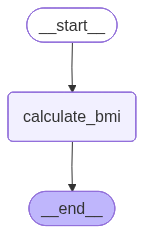

In [41]:
# to view the graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# Now making the workflow little complicated. 

Start -> bmi calculator -> label bmi category -> output

In [42]:
class bmi_state1(TypedDict):

    weight: float
    height: float
    bmi: float
    category: str

In [43]:
def bmi_calculator1(state:bmi_state1)-> bmi_state1:

    weight = state["weight"]
    height = state["height"]

    bmi = weight/(height**2)

    state["bmi"] = round(bmi,2)

    return state

In [44]:
def label_bmi(state:bmi_state1)-> bmi_state1:
    bmi = state["bmi"]
    if bmi < 18.5:
        state["category"]= "under-weight"
    elif 18.5 <= bmi < 25:
        state["category"] = "normal"
    elif 25<= bmi <30:
        state["category"] = "overweight"
    else:
        state["category"] = "obese"
    return state

In [45]:
graph1 = StateGraph(bmi_state1)

graph1.add_node("bmi_cal", bmi_calculator1)
graph1.add_node("label_bmi", label_bmi)

graph1.add_edge(START, "bmi_cal")
graph1.add_edge("bmi_cal", "label_bmi")
graph1.add_edge("label_bmi", END)

workflow1 = graph1.compile()


In [47]:
initia_state1 = {"weight": 45.1,'height':1.4}

final_output1 =  workflow1.invoke(initia_state1)
print(final_output1)

{'weight': 45.1, 'height': 1.4, 'bmi': 23.01, 'category': 'normal'}


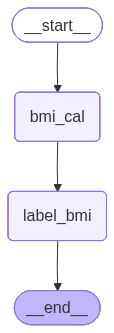

In [48]:
from IPython.display import Image
Image(workflow1.get_graph().draw_mermaid_png())